In [99]:
import duckdb
import numpy as np
import pandas as pd
import plotly.express as px
import json
import requests

In [100]:
def convert_damage(x):
    if not isinstance(x, str) or x.strip() == '':
        return pd.NA
    try:
        if 'K' in x:
            return int(float(x.replace('K', '')) * 1_000)
        elif 'M' in x:
            return int(float(x.replace('M', '')) * 1_000_000)
        else:
            return pd.NA
    except ValueError:
        return pd.NA

In [101]:
# for collab
from google.colab import drive
drive.mount('/content/drive')

def load_tornados_data():
    file_path = r"/content/drive/MyDrive/Colab Notebooks/project tornados/usa_tornados_xxi.csv"
    df = duckdb.sql(f"SELECT * FROM '{file_path}'").df()
    df.drop(columns=['column00', 'EVENT_TYPE'], inplace=True)
    df.columns = df.columns.map(lambda x: x.lower())
    date_columns = ['begin_date_time', 'end_date_time', 'fatality_date']
    df[date_columns[:2]] = df[date_columns[:2]].apply(lambda column: pd.to_datetime(column, format='%d-%b-%y %H:%M:%S', errors='coerce'))
    df[date_columns[2]] = df[date_columns[2]].apply(lambda column: pd.to_datetime(column, format='%m/%d/%Y %H:%M:%S', errors='coerce'))
    damage_columns = ['damage_property', 'damage_crops']
    df[damage_columns] =df[damage_columns].fillna('')
    df[damage_columns] = df[damage_columns].map(convert_damage).astype('Int64')
    fat_columns = ['fat_yearmonth', 'fat_day', 'fat_time', 'fatality_id']
    df[fat_columns] =df[fat_columns].astype('Int32')
    df['tor_f_scale'] = df['tor_f_scale'].map(lambda x: x.replace('E', '').replace('FU', 'unknown'))
    df['tor_length'] = round(df['tor_length'] * 1.60934, 2)
    df['tor_width'] = round(df['tor_width'] * 0.9144, 2)
    df['state'] = df['state'].map(lambda x: x.title())
    df['tor_duration_minutes'] = (df['end_date_time'] - df['begin_date_time']).map(lambda x: round(x.total_seconds() /60, 2))
    return df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
def load_states_geojson():
    url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
    response = requests.get(url)
    return response.json() if response.status_code == 200 else None

In [103]:
def draw_map(df, column):
    states_geojson = load_states_geojson()
    fig = px.choropleth(
        df,  # which dataframe to use, dataframe name
        geojson=states_geojson,
        locations="state",
        featureidkey="properties.name",
        color=column,  # which column values use for gradient colors, string
        color_continuous_scale='RdYlGn_r',
        projection="mercator",)
    fig.update_geos(
        center={"lat": 43, "lon": -120},
        projection_scale=3,
        visible=False,
        showland=True,
        landcolor="#E1B57F",
        showocean=False,
        bgcolor="rgba(0,0,0,0)",)
    fig.update_layout(
        margin={"r":0,"t":0,"l":0,"b":0},
        autosize=True,
        height=350,
        # width=800,
        coloraxis_colorbar=dict(title=''),
        paper_bgcolor="rgba(0,0,0,0)",)
    return fig

In [104]:
tornados = load_tornados_data() # our final dataset

In [105]:
# example of drawing map with function
tornados_locations = tornados.groupby('state').agg(tor_num=('event_id', 'nunique')).reset_index()
fig = draw_map(tornados_locations, 'tor_num')
fig.show()

# Analysis of deaths - Anna

I will analyze probability of being killled. Let's start with EDA on deaths specifically

In [106]:
# setting target variable
tornados['killed'] = ((tornados['deaths_direct'] + tornados['deaths_indirect']) > 0).astype(int)

In [107]:
tornados['killed'].value_counts(normalize=True) * 100

,proportion
killed,
0,94.994857
1,5.005143


We can see class imbalance. Deaths are being rare

Let's insert death rate from EDA above

In [108]:
deaths = pd.concat([tornados[['state']],
                   (tornados['deaths_direct'] + tornados['deaths_indirect']).rename('total_deaths')], axis=1)
deaths_per_state = deaths.groupby(['state']).agg(total_injuries=('total_deaths', 'mean'))
deaths_per_state.style.background_gradient(cmap='RdYlGn_r')

,total_injuries
state,
Alabama,2.992750
Alaska,0.000000
Arizona,0.000000
Arkansas,0.257166
California,0.000000
Colorado,0.004583
Connecticut,0.000000
Delaware,0.045455
District Of Columbia,0.000000


In [109]:
deaths_per_year = tornados[tornados['killed'] == 1].groupby(['year']).agg(total_deaths=('killed', 'count'))
deaths_per_year.style.background_gradient(cmap='RdYlGn_r')

,total_deaths
year,
2000,41
2001,33
2002,55
2003,53
2004,35
2005,37
2006,67
2007,81
2008,133


In [110]:
deaths_per_year = tornados[tornados['killed'] == 1].groupby(['year']).agg(total_deaths=('killed', 'count'))
deaths_per_year.style.background_gradient(cmap='RdYlGn_r')

,total_deaths
year,
2000,41
2001,33
2002,55
2003,53
2004,35
2005,37
2006,67
2007,81
2008,133


We can see that in 2011 amount of deaths peaked.

Some feature engeneering

In [111]:
tornados['tor_area'] = (tornados['tor_width'] * 0.001) * tornados['tor_length']

In [112]:
from geopy.distance import geodesic

def compute_distance(row):
    if pd.isna(row['begin_lat']) or pd.isna(row['begin_lon']) or pd.isna(row['end_lat']) or pd.isna(row['end_lon']):
        return np.nan
    start = (row['begin_lat'], row['begin_lon'])
    end = (row['end_lat'], row['end_lon'])
    return geodesic(start, end).km

tornados['path_distance_km'] = tornados.apply(compute_distance, axis=1)

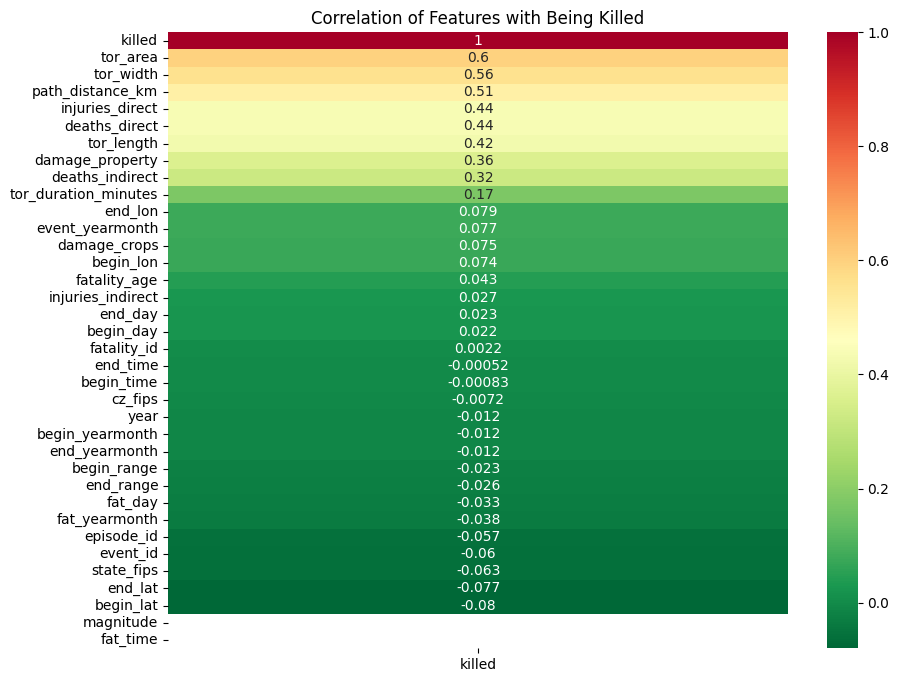

In [113]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

correlation = tornados.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(correlation[['killed']].sort_values(by='killed', ascending=False), annot=True, cmap='RdYlGn_r')
plt.title('Correlation of Features with Being Killed')
plt.show()

# Modelling

In [114]:
from sklearn.model_selection import train_test_split

tornados_train, tornados_test = train_test_split(tornados, test_size=0.2, random_state=10)

In [115]:
target = 'killed'

In [116]:
features = [
    'tor_area',
    'tor_width',
    'tor_length',
    'path_distance_km',
    'tor_duration_minutes',
    'state',
    'fatality_location'
]


X_train = tornados_train[features]
y_train = tornados_train[target]

In [117]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [118]:
num_features = [
    'tor_area',
    'tor_width',
    'tor_length',
    'path_distance_km',
    'tor_duration_minutes'
]

cat_features = [
    'fatality_location'
]

categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ]
)

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])



preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features)
])

In [119]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_model = Pipeline([
    ('preprocessing', preprocessor),
    ('rf', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'rf__max_depth': range(7, 12),
    'rf__class_weight': ['balanced', None],
    'rf__min_samples_split': range(2, 5),
    'rf__min_samples_leaf': [1, 2]
}

rf_grid_search = GridSearchCV(rf_model, rf_param_grid, cv=5, scoring='recall', n_jobs=-1)
rf_grid_search.fit(X_train, y_train)

print(rf_grid_search.best_params_)

{'rf__class_weight': 'balanced', 'rf__max_depth': 7, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2}


In [120]:
best_rf = rf_grid_search.best_estimator_

In [121]:
X_test = tornados_test[num_features + cat_features]
y_test = tornados_test[target]

In [122]:
preprocessor_fitted = best_rf.named_steps['preprocessing']
X_test_transformed = preprocessor_fitted.transform(X_test)
X_train_transformed = preprocessor_fitted.transform(X_train)


from sklearn.calibration import CalibratedClassifierCV

rf_clf = best_rf.named_steps['rf']

calibrated_rf = CalibratedClassifierCV(rf_clf, method='sigmoid', cv=5)
calibrated_rf.fit(X_train_transformed, y_train)

y_proba = calibrated_rf.predict_proba(X_test_transformed)[:, 1]

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros



In [123]:
importances = best_rf.named_steps['rf'].feature_importances_
feature_names = rf_grid_search.best_estimator_.named_steps['preprocessing'].transformers_[0][2]

In [124]:
def get_feature_names_from_preprocessor(preprocessor):
    feature_names = []

    for name, transformer, columns in preprocessor.transformers_:
        if name == 'remainder':
            continue

        if hasattr(transformer, 'get_feature_names_out'):
            try:
                names = transformer.get_feature_names_out(columns)
            except:
                names = columns
        else:
            names = columns

        feature_names.extend(names)

    return feature_names

In [125]:
preprocessor_fitted = best_rf.named_steps['preprocessing']
feature_names = get_feature_names_from_preprocessor(preprocessor_fitted)

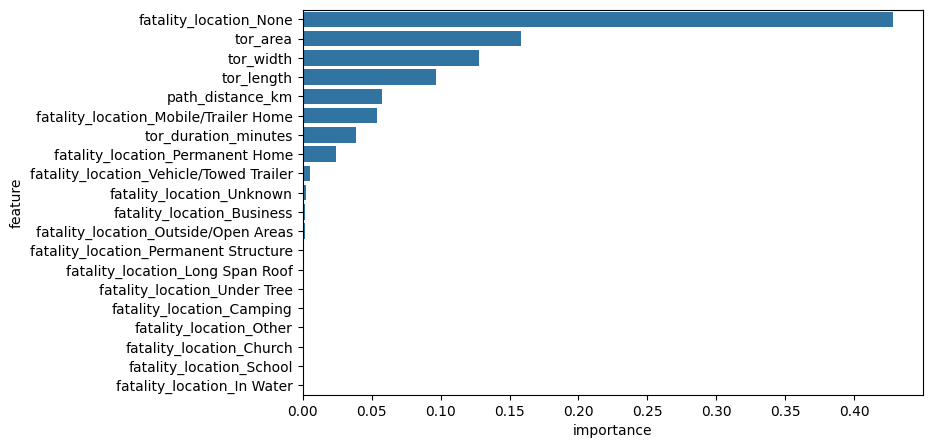

In [126]:
def plot_importances(importances, features, xlabel="importance"):
    df = pd.DataFrame({
        'feature': features,
        'importance': importances
    })
    df = df.sort_values('importance', ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x='importance', y='feature', data=df)
    plt.xlabel(xlabel)

plot_importances(importances, feature_names)

precision: (0.9918032786885246,), recall: (0.9864130434782609,), f1: (0.989100817438692,)


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros



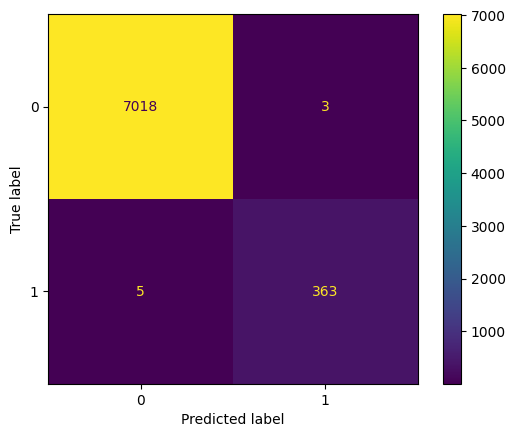

In [127]:
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, f1_score

y_test = tornados_test[target]
X_test = tornados_test.drop(columns=[target])
y_pred = best_rf.predict(X_test)

precision = precision_score(y_test, y_pred),
recall = recall_score(y_test, y_pred),
f1 = f1_score(y_test, y_pred),

print(f'precision: {precision}, recall: {recall}, f1: {f1}')

ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test)

Extracting probability

In [128]:
best_rf.predict_proba(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros



array([[0.99100451, 0.00899549],
       [0.00256344, 0.99743656],
       [0.0222169 , 0.9777831 ],
       ...,
       [0.95859783, 0.04140217],
       [0.97600774, 0.02399226],
       [0.99897963, 0.00102037]])

In [129]:
probas = best_rf.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros



Saving model

In [131]:
import joblib

joblib.dump(best_rf, '/content/drive/MyDrive/Colab Notebooks/project tornados/tornado_rf_pipeline_recall.pkl')

['/content/drive/MyDrive/Colab Notebooks/project tornados/tornado_rf_pipeline_recall.pkl']